# Mask-Selection Walkthrough (CTF frame, Subject17)

Illustrates Section 3.5 of the thesis step by step on a real scan. Each 3D
cell opens an **interactive** PyVista widget: rotate / pan / zoom until the
view is right for the thesis figure, then click the camera icon in the
PyVista toolbar to export a PNG. The matplotlib graphs (cap-boundary
profile, per-region counts) are saved to disk automatically because they
don't need camera control.

Pipeline (from Section 3.4's head-isolation output onward):

1. Start from the head-only mesh produced by `isolate_head`.
2. CTF alignment (`align_axes_from_landmarks`).
3. Midline Y-band used as input to the cap-boundary detector.
4. `detect_cap_boundary` -> `Z_cap`.
5. The cap boundary is a *ceiling*, not the full mask: everything above is
   spared, but inside the halfspace `Z < Z_cap` only the forward hemisphere
   and two ear spheres are deleted.
6. `face_mask_from_landmarks` -> union mask.
7. 8 mm landmark safe-area + nasion-strip carve-out (pipeline-level, see
   Section 3.6).
8. `delete_masked_vertices` and validation.

All math is in the CTF frame: **+X=anterior, +Y=left, +Z=up**, origin at the
LPA/RPA midpoint.

In [17]:
import logging
import os
from pathlib import Path

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import xarray as xr
import trimesh as _tm
from PIL import Image as _PILImage

import cedalion
import cedalion.dataclasses as cdc
import cedalion.io
import cedalion.vis.blocks
from cedalion.geometry.photogrammetry.anonymization import (
    normalize_axes,
    isolate_head,
    align_axes_from_landmarks,
    detect_cap_boundary,
    face_mask_from_landmarks,
    delete_masked_vertices,
    validate_anonymization,
)
from cedalion.vtktutils import trimesh_to_vtk_polydata
from cedalion.dataclasses import VTKSurface

logging.getLogger('cedalion').setLevel(logging.WARNING)
pv.set_jupyter_backend('server')

SUBJECT_NUMBER = 17
SCANS_FOLDER = '/home/ma7/BA/PG_Subjects'
FIG_DIR = Path('/home/ma7/Documents/BA_screenshots/mask_selection')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Matplotlib graphs -> {FIG_DIR}')
print('3D frames: use the camera icon in the PyVista toolbar to export a PNG.')

# Cached landmarks for Subject17 in raw Einstar coordinates.
# Re-pick in notebook 48 and overwrite these if the RPA validation fails.
LANDMARK_LABELS = ['Cz', 'Iz', 'Rpa', 'Nz', 'Lpa']
LANDMARK_COORDS_RAW = np.array([
    [182.65783971, 118.04228881, 431.56432941],  # Cz
    [ 55.89538812, 223.75583573, 451.320292  ],  # Iz
    [ 64.28395359,  88.3805534 , 585.72672053],  # Rpa
    [ 70.43872393, -12.48837767, 478.83735296],  # Nz
    [  1.44293713,  59.38634557, 399.68340223],  # Lpa
])

# Mask tunables (mm)
LANDMARK_KEEP_RADIUS = 8.0
EAR_DELETE_RADIUS_MM = 40.0

# Cap-boundary tunables
CAP_BAND_WIDTH_MM = 15.0
CAP_BIN_SIZE_MM = 2.0
CAP_FOOT_GRAD_THRESHOLD = 0.2

LM_COLORS = {'Nz': 'lime', 'Iz': 'magenta', 'Cz': 'cyan',
             'Lpa': 'orange', 'Rpa': 'blue'}


Matplotlib graphs -> /home/ma7/Documents/BA_screenshots/mask_selection
3D frames: use the camera icon in the PyVista toolbar to export a PNG.


## 1. Load and preprocess (up to the CTF-aligned head)

In [18]:
# Load the Einstar scan and ensure the texture is attached. Same fallback as
# notebook 48: trimesh 4.6 sometimes hides the image on .material.image.
path = f'{SCANS_FOLDER}/Subject{SUBJECT_NUMBER}/Subject{SUBJECT_NUMBER}.obj'
surface = cedalion.io.read_einstar_obj(path)

def _visual_image(visual):
    img = getattr(visual, 'image', None)
    if img is None:
        mat = getattr(visual, 'material', None)
        img = getattr(mat, 'image', None) if mat is not None else None
    return img

if _visual_image(surface.mesh.visual) is None:
    _jpg = path.replace('.obj', '.jpg')
    _uv = getattr(surface.mesh.visual, 'uv', None)
    assert os.path.exists(_jpg) and _uv is not None
    surface.mesh.visual = _tm.visual.TextureVisuals(
        uv=_uv, image=_PILImage.open(_jpg).convert('RGBA'),
    )

# Wrap cached landmarks.
landmarks_raw = xr.DataArray(
    LANDMARK_COORDS_RAW,
    dims=['label', 'digitized'],
    coords={
        'label': ('label', LANDMARK_LABELS),
        'type':  ('label', [cdc.PointType.LANDMARK] * 5),
        'group': ('label', ['L'] * 5),
    },
).pint.quantify('mm')
idx = {lbl: i for i, lbl in enumerate(landmarks_raw['label'].values)}

# normalize_axes + isolate_head (outputs of Sections 3.3 and 3.4).
lm_raw_xyz = landmarks_raw.pint.dequantify().values
Nz_raw = lm_raw_xyz[idx['Nz']]
surface_n, Nz_n, R = normalize_axes(surface, Nz_raw)
lm_normed_xyz = lm_raw_xyz @ R.T
surface_h_pre, _ = isolate_head(surface_n, Nz_n)

# CTF alignment: origin at the LPA/RPA midpoint, +X anterior, +Y left, +Z up.
landmarks_n = xr.DataArray(
    lm_normed_xyz, dims=['label', 'digitized'],
    coords={
        'label': ('label', LANDMARK_LABELS),
        'type':  ('label', [cdc.PointType.LANDMARK] * 5),
        'group': ('label', ['L'] * 5),
    },
).pint.quantify('mm')
surface_h, landmarks_ctf, _ = align_axes_from_landmarks(
    surface_h_pre, landmarks_n,
)
lm_ctf_xyz = landmarks_ctf.pint.dequantify().values
Nz, Iz, Cz, Lpa, Rpa = (lm_ctf_xyz[idx[lbl]]
                        for lbl in ['Nz', 'Iz', 'Cz', 'Lpa', 'Rpa'])
ear_mid = 0.5 * (Lpa + Rpa)
verts = np.asarray(surface_h.mesh.vertices)
mid_y = 0.5 * (Lpa[1] + Rpa[1])

print(f'Head-only mesh: {surface_h_pre.nvertices:,} verts')
print(f'CTF frame OK (crs={surface_h.crs!r}); ear_mid = {np.round(ear_mid,3)}')


Head-only mesh: 678,081 verts
CTF frame OK (crs='ctf'); ear_mid = [0. 0. 0.]


### Frame A — head-only mesh after `isolate_head` (Section 3.4 output)

The starting point for Section 3.5. Shoulders, chair, and disconnected
fragments have already been removed. Landmarks are drawn as coloured spheres
for orientation. Rotate the head to the angle you want, then use the
PyVista toolbar's camera icon to export a PNG.

In [19]:
pvplt = pv.Plotter()
hvtk = trimesh_to_vtk_polydata(surface_h_pre.mesh)
pvplt.add_mesh(pv.wrap(hvtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(LANDMARK_LABELS, lm_normed_xyz):
    c = LM_COLORS[lbl]
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=c)
    pvplt.add_point_labels([pos], [lbl], font_size=16, text_color=c,
                           shape=None, always_visible=True)
pvplt.add_text(
    f'After isolate_head  ({surface_h_pre.nvertices:,} verts)',
    position='upper_left', font_size=12,
)
pvplt.show()


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fae1c1863d0_10&reconnect=auto" class="pyv…

### Frame B — CTF-aligned mesh with basis vectors

After `align_axes_from_landmarks` the origin sits at the LPA/RPA midpoint and
the three coloured arrows mark the CTF axes:

- **red**  +X anterior (toward the nasion)
- **green** +Y left (toward LPA)
- **blue**  +Z up (toward Cz)

Every subsequent rule in Section 3.5 is expressed in this frame.

In [20]:
pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pvplt.add_mesh(pv.wrap(vtk_s.mesh), rgb=True, smooth_shading=True)

for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=LM_COLORS[lbl])
    pvplt.add_point_labels([pos], [lbl], font_size=16,
                           text_color=LM_COLORS[lbl],
                           shape=None, always_visible=True)

arr_len = 90.0
for direc, color, name in (
    ((1, 0, 0), 'red',   '+X anterior'),
    ((0, 1, 0), 'green', '+Y left'),
    ((0, 0, 1), 'blue',  '+Z up'),
):
    pvplt.add_mesh(
        pv.Arrow(start=(0, 0, 0), direction=direc, scale=arr_len),
        color=color,
    )
    tip = tuple(np.array(direc) * (arr_len + 15))
    pvplt.add_point_labels([tip], [name], font_size=16, text_color=color,
                           shape=None, always_visible=True)

pvplt.add_text('CTF frame: +X anterior, +Y left, +Z up',
               position='upper_left', font_size=12)
pvplt.show()


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fac8ae5c090_11&reconnect=auto" class="pyv…

## 2. Cap boundary detection

**Problem.** The fNIRS cap protrudes forward of the bare forehead, so if we
naively say "delete everything forward of the ear plane" we'd also delete
the cap, the optodes, and the cables. We need to stop the forward-facing
band at the cap's lower edge.

**Solution.** Walk upward along the midline and watch how far forward the
mesh reaches. On the forehead this distance grows slowly; at the cap edge it
jumps because the cap sticks out further than the skin below it. The cap
boundary height `Z_cap` is the foot of that jump.

### Frame C — midline Y-band feeding the profile

The cap detector only looks at vertices near the sagittal midline (within
±15 mm of `Y = 0`), above the nasion, and anterior to the ear plane. Those
are the blue vertices below.

In [21]:
in_band  = np.abs(verts[:, 1] - mid_y) < CAP_BAND_WIDTH_MM
above_nz = verts[:, 2] > Nz[2]
anterior = verts[:, 0] > ear_mid[0]
band_mask = in_band & above_nz & anterior
print(f'Midline-band vertices feeding the profile: {int(band_mask.sum()):,}')

pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pv_m = pv.wrap(vtk_s.mesh)
pv_m['band'] = band_mask.astype(float)
pvplt.add_mesh(pv_m, scalars='band', cmap=['#d6d6d6', '#1f77b4'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
pvplt.add_text(f'Midline Y-band  |Y| < {CAP_BAND_WIDTH_MM:.0f} mm',
               position='upper_left', font_size=12)
pvplt.show()


Midline-band vertices feeding the profile: 21,985


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fac8aed1350_12&reconnect=auto" class="pyv…

### Graph D — midline X(Z) profile and its gradient

The blue vertices are binned by height `Z` in 2 mm bins and the max
anterior extent `X` per bin forms the profile `X(Z)` (left panel). The
Savitzky–Golay smoothing suppresses sub-millimetre scanner noise. The
cap sits at the top of the steep rise; `Z_cap` is the first Z, walking back
from the smoothed peak toward the nasion, where the gradient `dX/dZ` drops
below the foot threshold `0.2` (right panel).

Z_cap = 31.0 mm   (Nz_z=-0.0, Cz_z=165.4)


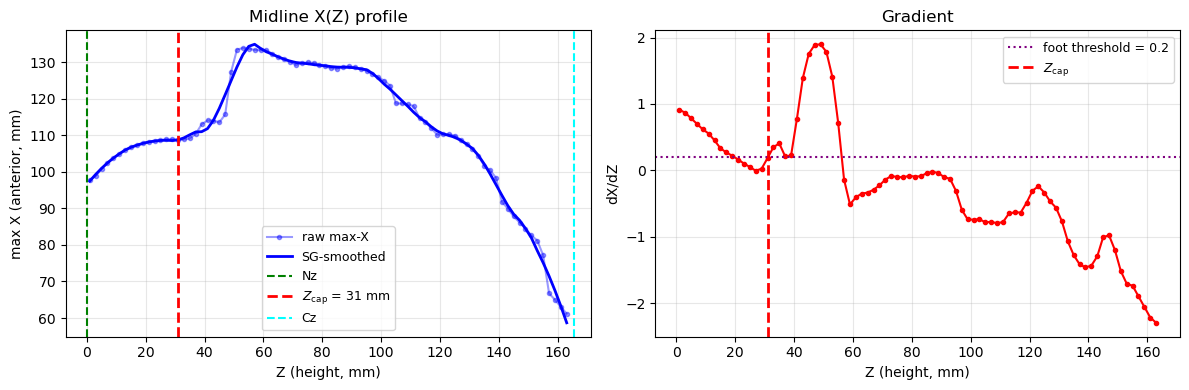

Saved 06_cap_profile.pdf and .png  (Z_cap = 31.0 mm)


In [22]:
cap_z, profile_z, profile_x, profile_x_s = detect_cap_boundary(
    verts, Nz, Cz, ear_mid, mid_y,
    band_width=CAP_BAND_WIDTH_MM,
    bin_size=CAP_BIN_SIZE_MM,
    foot_grad_threshold=CAP_FOOT_GRAD_THRESHOLD,
)
print(f'Z_cap = {cap_z:.1f} mm   (Nz_z={Nz[2]:.1f}, Cz_z={Cz[2]:.1f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(profile_z, profile_x, 'b.-', alpha=0.4, label='raw max-X')
ax1.plot(profile_z, profile_x_s, 'b-', lw=2, label='SG-smoothed')
ax1.axvline(Nz[2], color='green', ls='--', label='Nz')
ax1.axvline(cap_z, color='red', ls='--', lw=2,
            label=f'$Z_\\mathrm{{cap}}$ = {cap_z:.0f} mm')
ax1.axvline(Cz[2], color='cyan', ls='--', label='Cz')
ax1.set_xlabel('Z (height, mm)')
ax1.set_ylabel('max X (anterior, mm)')
ax1.set_title('Midline X(Z) profile')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)

grad = np.gradient(profile_x_s, profile_z)
ax2.plot(profile_z, grad, 'r.-')
ax2.axhline(CAP_FOOT_GRAD_THRESHOLD, color='purple', ls=':',
            label=f'foot threshold = {CAP_FOOT_GRAD_THRESHOLD}')
ax2.axvline(cap_z, color='red', ls='--', lw=2, label='$Z_\\mathrm{cap}$')
ax2.set_xlabel('Z (height, mm)')
ax2.set_ylabel('dX/dZ')
ax2.set_title('Gradient')
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_cap_profile.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / '06_cap_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved 06_cap_profile.pdf and .png  (Z_cap = {cap_z:.1f} mm)')


### Frame E — cap boundary plane on the mesh

The semi-transparent red plane is the horizontal slice at `Z = Z_cap`.
Everything above it is *guaranteed* to survive; everything below it is
*eligible* for masking (but not automatically masked — see the next
section).

In [23]:
pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pvplt.add_mesh(pv.wrap(vtk_s.mesh), color='#c8c8c8', smooth_shading=True)
plane = pv.Plane(center=(0.0, 0.0, float(cap_z)),
                 direction=(0.0, 0.0, 1.0),
                 i_size=320.0, j_size=320.0)
pvplt.add_mesh(plane, color='red', opacity=0.35)
pvplt.add_text(f'Cap boundary plane  Z = {cap_z:.0f} mm',
               position='upper_left', font_size=12)
pvplt.show()


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fae07f37050_13&reconnect=auto" class="pyv…

## 3. From the cap boundary to the final mask

`Z_cap` is a **ceiling**, not the mask itself. If we masked *everything* below
`Z_cap` we would delete the posterior scalp, the neck, and the shoulders
too — far more than we want. Frame F shows that `below_cap` halfspace as a
sanity check; the final mask is a much smaller subset of it.

Inside the halfspace `Z < Z_cap`, the mask is the **union** of two
geometric regions:

1. **Face region** (Frame G): every vertex with `X > M_X`, i.e. in front of
   the coronal plane that passes through the ear midpoint `M`. This covers
   the face, the cheeks, and the forehead up to the cap edge.
2. **Ear spheres** (Frames H and I): two 40 mm spheres centred on LPA and
   RPA respectively. These sweep up each pinna and the surrounding lateral
   skin.

Everything else — the back of the head, the crown under the cap, the neck,
the shoulders — is *not* in either region and is therefore kept.

### Frame F — `below_cap` halfspace (eligibility only, not the mask)

Blue = vertices with `Z < Z_cap`. Note how much of the head this covers;
the final mask is narrower.

In [24]:
below_cap = verts[:, 2] < cap_z

pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pv_m = pv.wrap(vtk_s.mesh)
pv_m['below'] = below_cap.astype(float)
pvplt.add_mesh(pv_m, scalars='below', cmap=['#d6d6d6', '#1f77b4'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
pvplt.add_text(
    f'below_cap halfspace  Z < {cap_z:.0f} mm  '
    f'({int(below_cap.sum()):,} verts eligible)',
    position='upper_left', font_size=12,
)
pvplt.show()


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fadec0aab50_14&reconnect=auto" class="pyv…

### Frame G — face region `X > M_X` ∧ `Z < Z_cap`

Red = the forward hemisphere below the cap. Rotate to a 3/4 frontal view
for the thesis figure.

In [25]:
anterior_m  = verts[:, 0] > ear_mid[0]
face_region = below_cap & anterior_m
print(f'face_region vertices: {int(face_region.sum()):,}')

pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pv_m = pv.wrap(vtk_s.mesh)
pv_m['face'] = face_region.astype(float)
pvplt.add_mesh(pv_m, scalars='face', cmap=['#d6d6d6', 'red'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
pvplt.add_text(f'Face region  X > M_X ∧ Z < Z_cap  '
               f'({int(face_region.sum()):,} verts)',
               position='upper_left', font_size=12)
pvplt.show()


face_region vertices: 102,705


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fadab700ed0_15&reconnect=auto" class="pyv…

### Frame H — ear spheres, mirrored side-by-side

Left panel: LPA sphere viewed from the subject's left (camera at `+Y`).
Right panel: RPA sphere viewed from the subject's right (camera at `-Y`).
Both are 40 mm spheres clamped below the cap. The cameras are mirrored,
not linked — you can tweak each side independently before screenshotting.

In [26]:
d_lpa = np.linalg.norm(verts - Lpa, axis=1)
d_rpa = np.linalg.norm(verts - Rpa, axis=1)
lpa_region = (d_lpa < EAR_DELETE_RADIUS_MM) & below_cap
rpa_region = (d_rpa < EAR_DELETE_RADIUS_MM) & below_cap
ear_region = lpa_region | rpa_region
print(f'LPA ear verts: {int(lpa_region.sum()):,}   '
      f'RPA ear verts: {int(rpa_region.sum()):,}   '
      f'(union {int(ear_region.sum()):,})')

# Mirrored lateral cameras. Focal point = ear midpoint (CTF origin).
CAM_DIST = 420.0
CAM_LEFT  = [(0.0,  CAM_DIST, float(Cz[2]) * 0.25),
             (0.0, 0.0, float(Cz[2]) * 0.25),
             (0.0, 0.0, 1.0)]
CAM_RIGHT = [(0.0, -CAM_DIST, float(Cz[2]) * 0.25),
             (0.0, 0.0, float(Cz[2]) * 0.25),
             (0.0, 0.0, 1.0)]

pvplt = pv.Plotter(shape=(1, 2))

# --- left panel: LPA ---
pvplt.subplot(0, 0)
vtk_a = VTKSurface.from_trimeshsurface(surface_h)
pv_a = pv.wrap(vtk_a.mesh)
pv_a['lpa'] = lpa_region.astype(float)
pvplt.add_mesh(pv_a, scalars='lpa', cmap=['#d6d6d6', 'orange'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
pvplt.add_mesh(pv.Sphere(radius=5, center=Lpa), color=LM_COLORS['Lpa'])
pvplt.add_point_labels([Lpa], ['Lpa'], font_size=16,
                       text_color=LM_COLORS['Lpa'],
                       shape=None, always_visible=True)
pvplt.camera_position = CAM_LEFT
pvplt.add_text(f'LPA sphere (r = {EAR_DELETE_RADIUS_MM:.0f} mm)  '
               f'{int(lpa_region.sum()):,} verts',
               position='upper_left', font_size=12)

# --- right panel: RPA ---
pvplt.subplot(0, 1)
vtk_b = VTKSurface.from_trimeshsurface(surface_h)
pv_b = pv.wrap(vtk_b.mesh)
pv_b['rpa'] = rpa_region.astype(float)
pvplt.add_mesh(pv_b, scalars='rpa', cmap=['#d6d6d6', 'orange'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
pvplt.add_mesh(pv.Sphere(radius=5, center=Rpa), color=LM_COLORS['Rpa'])
pvplt.add_point_labels([Rpa], ['Rpa'], font_size=16,
                       text_color=LM_COLORS['Rpa'],
                       shape=None, always_visible=True)
pvplt.camera_position = CAM_RIGHT
pvplt.add_text(f'RPA sphere (r = {EAR_DELETE_RADIUS_MM:.0f} mm)  '
               f'{int(rpa_region.sum()):,} verts',
               position='upper_left', font_size=12)

pvplt.show()


LPA ear verts: 19,573   RPA ear verts: 11,655   (union 31,228)


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fadab753a90_16&reconnect=auto" class="pyv…

### Frame J — union mask (before carve-outs)

Red = the union of the face region and the two ear spheres. This is what
`face_mask_from_landmarks` returns.

In [27]:
mask, mask_info = face_mask_from_landmarks(
    verts, Nz, Iz, Cz, Lpa, Rpa,
    cap_z=cap_z, ear_delete_radius=EAR_DELETE_RADIUS_MM,
)
counts_pre = dict(mask_info['counts'])
mask_pre_carve = mask.copy()
print(f'Pre-carveout counts: {counts_pre}')

pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pv_m = pv.wrap(vtk_s.mesh)
pv_m['mask'] = mask_pre_carve.astype(float)
pvplt.add_mesh(pv_m, scalars='mask', cmap=['white', 'red'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    c = LM_COLORS[lbl]
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=c)
    pvplt.add_point_labels([pos], [lbl], font_size=16, text_color=c,
                           shape=None, always_visible=True)
pvplt.add_text(
    f'Union mask, pre-carveout  '
    f'({int(mask_pre_carve.sum()):,} verts, '
    f'{100*mask_pre_carve.sum()/len(mask_pre_carve):.1f} %)',
    position='upper_left', font_size=12,
)
pvplt.show()


Pre-carveout counts: {'below_cap': 304744, 'face_region': 102705, 'ear_region': 31228, 'all': 117625}


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fadab763390_17&reconnect=auto" class="pyv…

### Frame K — final mask after the landmark safe-area and nasion-strip carve-outs

Before the mask is handed to the deletion step, two carve-outs run at the
pipeline level (Section 3.6):

- an 8 mm spherical *safe-area* around each of the five landmarks is
  removed from the mask, and
- a narrow midline strip running from the nasion up to `Z_cap` is also
  removed, so Cedalion's `LandmarksBuilder1010` retains a clean nasion
  neighbourhood.

The result is what actually gets deleted.

In [28]:
for lm in (Nz, Iz, Cz, Lpa, Rpa):
    near = np.linalg.norm(verts - lm, axis=1) < LANDMARK_KEEP_RADIUS
    mask[near] = False
nasion_strip = (
    (verts[:, 2] >= Nz[2]) & (verts[:, 2] < cap_z)
    & (np.abs(verts[:, 1] - Nz[1]) < LANDMARK_KEEP_RADIUS)
    & (verts[:, 0] > ear_mid[0])
)
mask[nasion_strip] = False
print(f'Final mask: {int(mask.sum()):,} verts '
      f'({100*mask.sum()/len(mask):.1f} %)')

pvplt = pv.Plotter()
vtk_s = VTKSurface.from_trimeshsurface(surface_h)
pv_m = pv.wrap(vtk_s.mesh)
pv_m['mask'] = mask.astype(float)
pvplt.add_mesh(pv_m, scalars='mask', cmap=['white', 'red'],
               clim=[0, 1], show_scalar_bar=False, smooth_shading=True)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    c = LM_COLORS[lbl]
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=c)
    pvplt.add_point_labels([pos], [lbl], font_size=16, text_color=c,
                           shape=None, always_visible=True)
pvplt.add_text(
    f'Final mask (after carve-outs)  '
    f'{int(mask.sum()):,} / {len(mask):,} verts  '
    f'({100*mask.sum()/len(mask):.1f} %)',
    position='upper_left', font_size=12,
)
pvplt.show()


Final mask: 114,837 verts (16.9 %)


Widget(value='<iframe src="http://localhost:32931/index.html?ui=P_0x7fadab7e3e10_18&reconnect=auto" class="pyv…

### Graph L — per-region vertex counts

How the mask budget splits by geometric rule (pre-carveout) and after the
safe-area carve-outs.

In [ ]:
labels  = ['below_cap', 'face_region', 'ear_region',
           'union (pre-carve)', 'final mask']
values  = [counts_pre['below_cap'], counts_pre['face_region'],
           counts_pre['ear_region'], counts_pre['all'], int(mask.sum())]
colors  = ['#8a8a8a', '#d62728', '#ff7f0e', '#9467bd', '#2ca02c']

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v,
            f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('vertex count')
ax.set_title(f'Per-region mask counts  (Subject{SUBJECT_NUMBER})')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / '11_region_counts.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / '11_region_counts.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Deletion and before/after

Once the mask is finalized, `delete_masked_vertices` drops every triangle
touching a masked vertex and strips the now-unreferenced vertices. No
smoothing, no Taubin pass (see Section 3.6).

### Frame M — anonymized mesh

In [ ]:
surface_anon = delete_masked_vertices(surface_h, mask)
n_removed = surface_h.nvertices - surface_anon.nvertices
print(f'Original:    {surface_h.nvertices:,} verts')
print(f'Anonymized:  {surface_anon.nvertices:,} verts  (-{n_removed:,})')

pvplt = pv.Plotter()
anon_vtk = trimesh_to_vtk_polydata(surface_anon.mesh)
pvplt.add_mesh(pv.wrap(anon_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=LM_COLORS[lbl])
pvplt.add_text(
    f'Anonymized  ({surface_anon.nvertices:,} verts, -{n_removed:,})',
    position='upper_left', font_size=12,
)
pvplt.show()


### Frame N — before / after (linked views)

Rotate either panel; both cameras move together.

In [ ]:
pvplt = pv.Plotter(shape=(1, 2))

pvplt.subplot(0, 0)
orig_vtk = trimesh_to_vtk_polydata(surface_h.mesh)
pvplt.add_mesh(pv.wrap(orig_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=LM_COLORS[lbl])
pvplt.add_text(f'Subject{SUBJECT_NUMBER} original',
               position='upper_left', font_size=12)

pvplt.subplot(0, 1)
anon_vtk = trimesh_to_vtk_polydata(surface_anon.mesh)
pvplt.add_mesh(pv.wrap(anon_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    pvplt.add_mesh(pv.Sphere(radius=5, center=pos), color=LM_COLORS[lbl])
pvplt.add_text(f'Anonymized  (-{n_removed:,} verts)',
               position='upper_left', font_size=12)

pvplt.link_views()
pvplt.show()


## 5. Validation

Sanity-check the anonymized mesh against the original.

In [ ]:
result = validate_anonymization(
    original_surface=surface_h,
    anonymized_surface=surface_anon,
    facial_mask=mask,
    protected_points=landmarks_ctf,
)
print(result)